# Mining performance analysis

Reads all `*_report.json` files found recursively under a results root.
Derives dataset, endpoint type (`remote` / `qlever`), strategy variant, and
parameter configuration from the directory structure.

In [ ]:
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

RESULTS_ROOT = Path(__file__).parent.parent / "results" if "__file__" in dir() else Path("../../") / "results"

# index_warnings.json: written by run_pipeline.sh into /output (=RESULTS_ROOT
# when running inside the container, or results/ on the host after step 15).
# Override via INDEX_WARNINGS env var, e.g. when running manually.
_warn_env = os.environ.get("INDEX_WARNINGS")
INDEX_WARNINGS_PATH = (
    Path(_warn_env) if _warn_env
    else RESULTS_ROOT / "index_warnings.json"
)

# matplotlib style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

## Collect all report files

In [33]:
def _parse_config_label(label: str) -> dict:
    """
    Parse a parameter-config directory name into numeric fields.

    Recognised patterns:
      one_shot
      chunk<N>_batch<M>
      chunk<N>_batch<M>_cc<K>
    """
    if label == "one_shot":
        return {"one_shot": True, "chunk_size": None, "class_batch_size": None, "class_chunk_size": None}
    m = re.fullmatch(r"chunk(\d+)_batch(\d+)(?:_cc(\d+))?", label)
    if m:
        return {
            "one_shot": False,
            "chunk_size": int(m.group(1)),
            "class_batch_size": int(m.group(2)),
            "class_chunk_size": int(m.group(3)) if m.group(3) else None,
        }
    return {"one_shot": False, "chunk_size": None, "class_batch_size": None, "class_chunk_size": None}


def collect_reports(root: Path) -> pd.DataFrame:
    """
    Walk *root* recursively and load every *_report.json.

    Supported directory structures
    (both old flat layout and new per-dataset layout are recognised):

      New (per-dataset, structured):
        <root>/<dataset>/remote/<strategy>/<config>/*_report.json
        <root>/<dataset>/qlever/<strategy>/<config>/*_report.json

      Old (flat, legacy):
        <root>/<dataset>/*_mined_remote_report.json   (remote, config="remote")
        <root>/<dataset>/qlever/<strategy>/<config>/  (qlever - same as new)
    """
    records = []
    for report_path in sorted(root.rglob("*_report.json")):
        try:
            with report_path.open(encoding="utf-8") as f:
                r = json.load(f)
        except Exception:
            continue

        rel_parts = report_path.relative_to(root).parts
        # rel_parts[0] is always the dataset directory name.

        # Locate the endpoint-type marker ("qlever" or "remote") in the path.
        # New layout: <dataset>/qlever/<strat>/<cfg>/file  -> marker at index 1
        # New layout: <dataset>/remote/<strat>/<cfg>/file  -> marker at index 1
        # Old layout: <dataset>/file                        -> no marker
        marker_idx = next(
            (i for i, p in enumerate(rel_parts) if p in ("qlever", "remote")),
            None,
        )

        if marker_idx is not None:
            endpoint_type    = rel_parts[marker_idx]          # "qlever" or "remote"
            strategy_variant = rel_parts[marker_idx + 1] if marker_idx + 1 < len(rel_parts) else "unknown"
            config_label     = rel_parts[marker_idx + 2] if marker_idx + 2 < len(rel_parts) else "unknown"
        else:
            # Legacy flat remote report sitting directly in the dataset dir.
            endpoint_type    = "remote"
            strategy_variant = r.get("strategy", "typed")
            config_label     = "remote"

        cfg_fields = _parse_config_label(config_label)
        # class_batch_size is encoded in the directory name only (not in config dict)
        cfg_from_dir_batch = cfg_fields["class_batch_size"]

        bm = r.get("benchmark") or {}
        qs = r.get("query_stats") or {}

        def phase_time(prefix):
            return sum(
                v.get("total_time_s", 0)
                for k, v in qs.items()
                if k.startswith(prefix)
            )

        # phases list gives per-phase wall durations directly from the runner
        phases = {ph["name"]: ph.get("duration_s", 0) for ph in (r.get("phases") or [])}

        rec = {
            # identity
            "dataset":           r.get("dataset_name", rel_parts[0]),
            "endpoint_type":     endpoint_type,
            "strategy_variant":  strategy_variant,
            "config_label":      config_label,
            "report_path":       str(report_path),
            # config params - chunk_size is in config dict; batch from dir name
            "one_shot":          cfg_fields["one_shot"],
            "chunk_size":        r.get("config", {}).get("chunk_size") or cfg_fields["chunk_size"],
            "class_batch_size":  cfg_from_dir_batch,
            "class_chunk_size":  r.get("config", {}).get("class_chunk_size") or cfg_fields["class_chunk_size"],
            "untyped_as_classes": r.get("config", {}).get("untyped_as_classes", False),
            # timing (wall_time_s = full process incl. startup; total_duration_s = pure SPARQL work)
            "total_duration_s":  r.get("total_duration_s"),
            "wall_time_s":       bm.get("wall_time_s"),
            "cpu_user_s":        bm.get("cpu_user_s"),
            "peak_rss_mb":       bm.get("peak_rss_mb"),
            # query counts
            "total_queries_sent":   r.get("total_queries_sent"),
            "total_queries_failed": r.get("total_queries_failed"),
            # phase wall durations (from phases list - more accurate than summing query_stats)
            "t_class_discovery_s":  phases.get("class-discovery", 0),
            "t_per_class_s":        phases.get("per-class-patterns", 0),
            "t_counts_s":           phases.get("counts", 0),
            "t_labels_s":           phases.get("labels", 0),
            # query_stats time breakdown (SPARQL round-trip time only, no Python overhead)
            "qt_classes_s":      phase_time("two-phase/classes"),
            "qt_typed_object_s": phase_time("two-phase/typed-object") + phase_time("counts/typed-object"),
            "qt_literal_s":      phase_time("two-phase/literal")      + phase_time("counts/literal"),
            "qt_untyped_uri_s":  phase_time("two-phase/untyped-uri")  + phase_time("counts/untyped-uri"),
            "qt_one_shot_s":     phase_time("one-shot/"),
            "qt_labels_s":       phase_time("labels"),
            # output
            "pattern_count":   r.get("pattern_count"),
            "class_count":     r.get("class_count"),
            "property_count":  r.get("property_count"),
            "abort_reason":    r.get("abort_reason"),
            "success":         bm.get("success", True),
            "qlever_git_hash": (r.get("qlever_version") or {}).get("git_hash_server"),
            # one-shot per-query results (list or None)
            "one_shot_results": r.get("one_shot_results"),
        }
        records.append(rec)

    df = pd.DataFrame(records)
    for col in ["chunk_size", "class_batch_size", "total_queries_sent",
                "pattern_count", "class_count", "property_count"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


df = collect_reports(RESULTS_ROOT)
print(f"Reports found: {len(df)}")
df[["dataset", "endpoint_type", "strategy_variant", "config_label",
    "chunk_size", "class_batch_size", "pattern_count", "class_count",
    "total_duration_s", "wall_time_s"]].sort_values(
        ["dataset", "endpoint_type", "strategy_variant", "config_label"]
    )


Reports found: 2


,dataset,endpoint_type,strategy_variant,config_label,chunk_size,class_batch_size,pattern_count,class_count,total_duration_s,wall_time_s
0,aopwikirdf,qlever,typed,one_shot,10000,NaN,262,28,2.620,7.587
1,wikipathways,qlever,typed,one_shot,10000,NaN,1221,39,41.418,46.247


## Enrich with triple counts from QLever index metadata

QLever writes `<name>.meta-data.json` into the workdir after indexing.
We read `num-triples.normal` from there and join it onto the report table.

In [34]:
def collect_triple_counts(root: Path) -> dict:
    """
    Scan for QLever <name>.meta-data.json files under *root*.
    Returns {dataset_name: num_triples}.
    """
    counts = {}
    for p in root.rglob("*.meta-data.json"):
        try:
            with p.open(encoding="utf-8") as f:
                meta = json.load(f)
            n = meta.get("num-triples", {}).get("normal")
            if n is not None:
                # dataset name is the stem before ".meta-data"
                name = p.name.replace(".meta-data.json", "")
                counts[name] = int(n)
        except Exception:
            continue
    return counts


triple_counts = collect_triple_counts(RESULTS_ROOT)
print("Triple counts found:", triple_counts)

df["triple_count"] = df["dataset"].map(triple_counts)
df[["dataset", "triple_count"]].drop_duplicates()

Triple counts found: {'aopwikirdf': 201419, 'wikipathways': 11001952}


,dataset,triple_count
0,aopwikirdf,201419
1,wikipathways,11001952


## Wall time vs chunk size (QLever, paginated passes)

Effect of page size and class-batch size on total wall time.
One subplot per dataset × strategy variant combination.

In [35]:
pag = df[(df["endpoint_type"] == "qlever") & (~df["one_shot"])].copy()

if pag.empty:
    print("No paginated QLever runs found.")
else:
    groups = pag.groupby(["dataset", "strategy_variant"])
    ncols = 2
    nrows = max(1, -(-len(groups) // ncols))   # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax_idx, ((dataset, variant), grp) in enumerate(groups):
        ax = axes_flat[ax_idx]
        for batch, sub in grp.groupby("class_batch_size"):
            sub_s = sub.sort_values("chunk_size")
            ax.plot(sub_s["chunk_size"], sub_s["wall_time_s"],
                    marker="o", label=f"batch={batch}")
        ax.set_title(f"{dataset} / {variant}")
        ax.set_xlabel("chunk size (rows/page)")
        ax.set_ylabel("wall time (s)")
        ax.legend(title="class batch", fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    for ax in axes_flat[len(groups):]:
        ax.set_visible(False)

    fig.suptitle("Wall time vs chunk size - QLever paginated mining", y=1.01)
    fig.tight_layout()
    plt.show()

No paginated QLever runs found.


## Query count vs chunk size

Smaller pages -> more round-trips. Shows the cost of fine-grained pagination.

In [36]:
if pag.empty:
    print("No paginated QLever runs found.")
else:
    groups = pag.groupby(["dataset", "strategy_variant"])
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for ax_idx, ((dataset, variant), grp) in enumerate(groups):
        ax = axes_flat[ax_idx]
        for batch, sub in grp.groupby("class_batch_size"):
            sub_s = sub.sort_values("chunk_size")
            ax.plot(sub_s["chunk_size"], sub_s["total_queries_sent"],
                    marker="s", label=f"batch={batch}")
        ax.set_title(f"{dataset} / {variant}")
        ax.set_xlabel("chunk size (rows/page)")
        ax.set_ylabel("total queries sent")
        ax.legend(title="class batch", fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    for ax in axes_flat[len(groups):]:
        ax.set_visible(False)

    fig.suptitle("Query count vs chunk size - QLever paginated mining", y=1.01)
    fig.tight_layout()
    plt.show()

No paginated QLever runs found.


## Query time breakdown by phase

Stacked bars showing time spent in each query phase (class discovery, typed-object, literal, untyped-uri, labels).
One bar per (config × strategy variant), grouped by dataset.

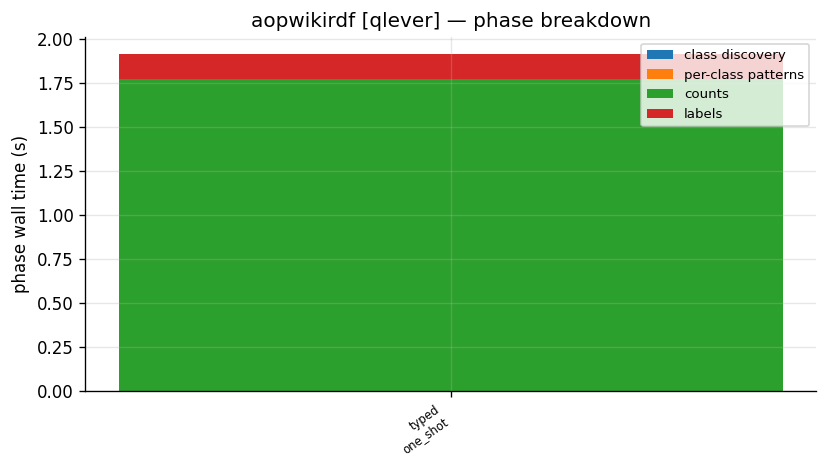

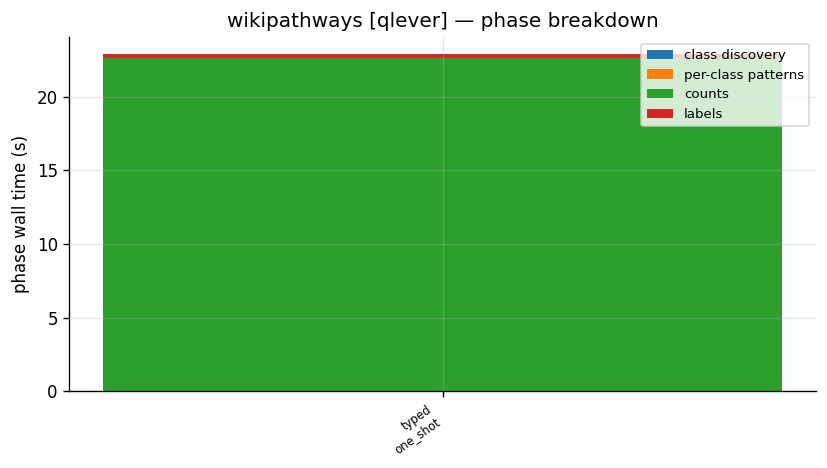

In [37]:
# Phase wall-clock durations: class-discovery / per-class / counts / labels
phase_cols   = ["t_class_discovery_s", "t_per_class_s", "t_counts_s", "t_labels_s"]
phase_labels = ["class discovery",     "per-class patterns", "counts", "labels"]

for endpoint, grp_top in df.groupby("endpoint_type"):
    for dataset, grp in grp_top.groupby("dataset"):
        grp = grp.sort_values(["strategy_variant", "config_label"]).reset_index(drop=True)
        bar_labels = grp["strategy_variant"] + "\n" + grp["config_label"]

        fig, ax = plt.subplots(figsize=(max(7, len(grp) * 0.85), 4))
        bottom = [0.0] * len(grp)
        for col, lbl in zip(phase_cols, phase_labels, strict=False):
            vals = grp[col].fillna(0).tolist()
            ax.bar(range(len(grp)), vals, bottom=bottom, label=lbl, width=0.6)
            bottom = [b + v for b, v in zip(bottom, vals, strict=False)]

        ax.set_xticks(range(len(grp)))
        ax.set_xticklabels(bar_labels, fontsize=7, rotation=35, ha="right")
        ax.set_ylabel("phase wall time (s)")
        ax.set_title(f"{dataset} [{endpoint}] - phase breakdown")
        ax.legend(loc="upper right", fontsize=8)
        fig.tight_layout()
        plt.show()


## Pattern count: typed vs untyped strategy

Compares how many patterns (subject-predicate-object type triples) each strategy finds
across chunk/batch configurations. Completeness should be stable across configs for the same strategy.

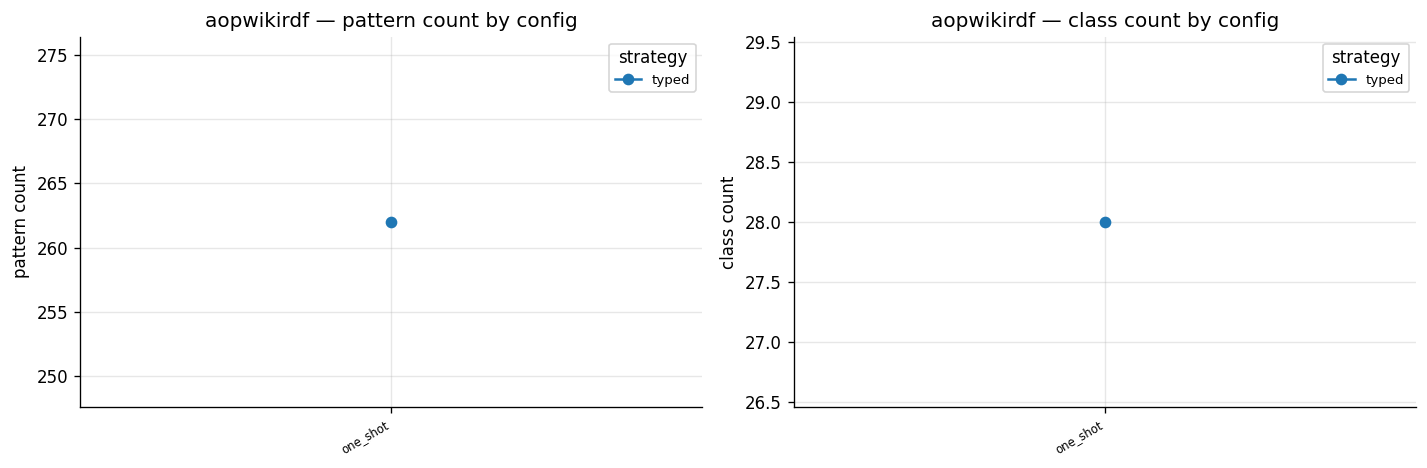

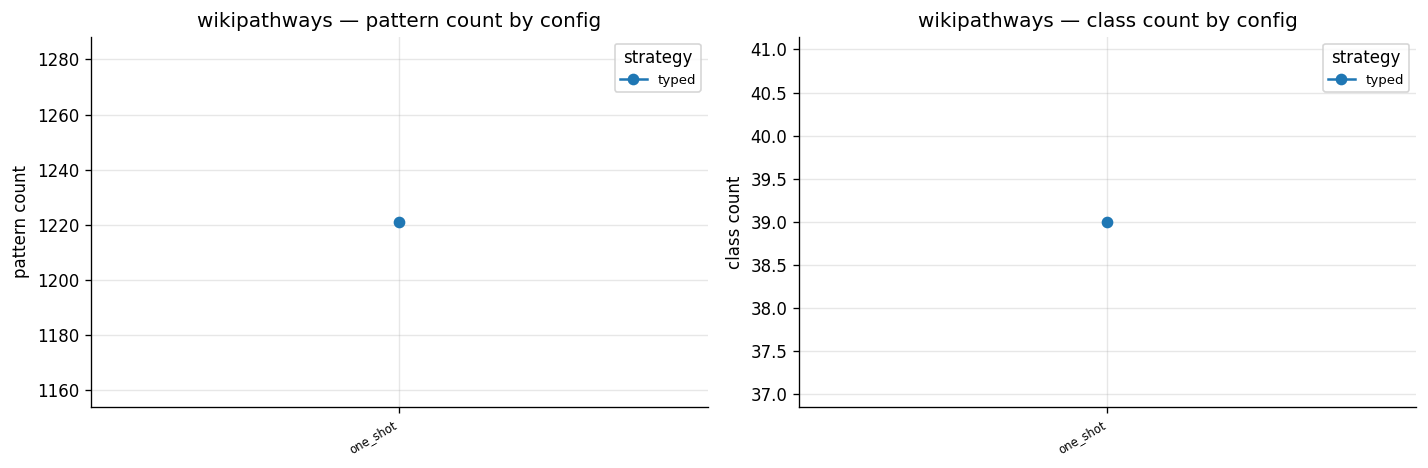

In [38]:
for dataset, grp in df[df["endpoint_type"] == "qlever"].groupby("dataset"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, metric, ylabel in zip(
        axes,
        ["pattern_count", "class_count"],
        ["pattern count", "class count"], strict=False,
    ):
        for variant, sub in grp.groupby("strategy_variant"):
            sub_s = sub.sort_values("config_label")
            ax.plot(range(len(sub_s)), sub_s[metric], marker="o", label=variant)
            ax.set_xticks(range(len(sub_s)))
            ax.set_xticklabels(sub_s["config_label"], rotation=30, ha="right", fontsize=7)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{dataset} - {ylabel} by config")
        ax.legend(title="strategy", fontsize=8)

    fig.tight_layout()
    plt.show()

## Remote vs QLever (best local config): wall time and pattern count

Compares remote mining against the best-performing QLever config (lowest wall time)
for each dataset × strategy combination.

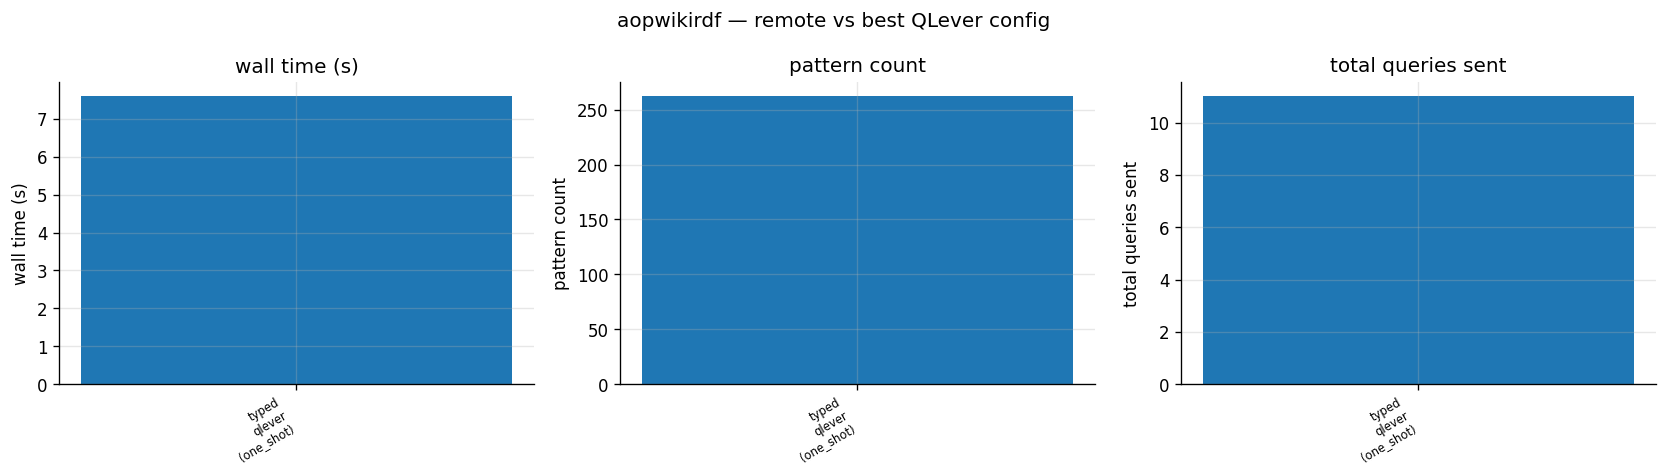

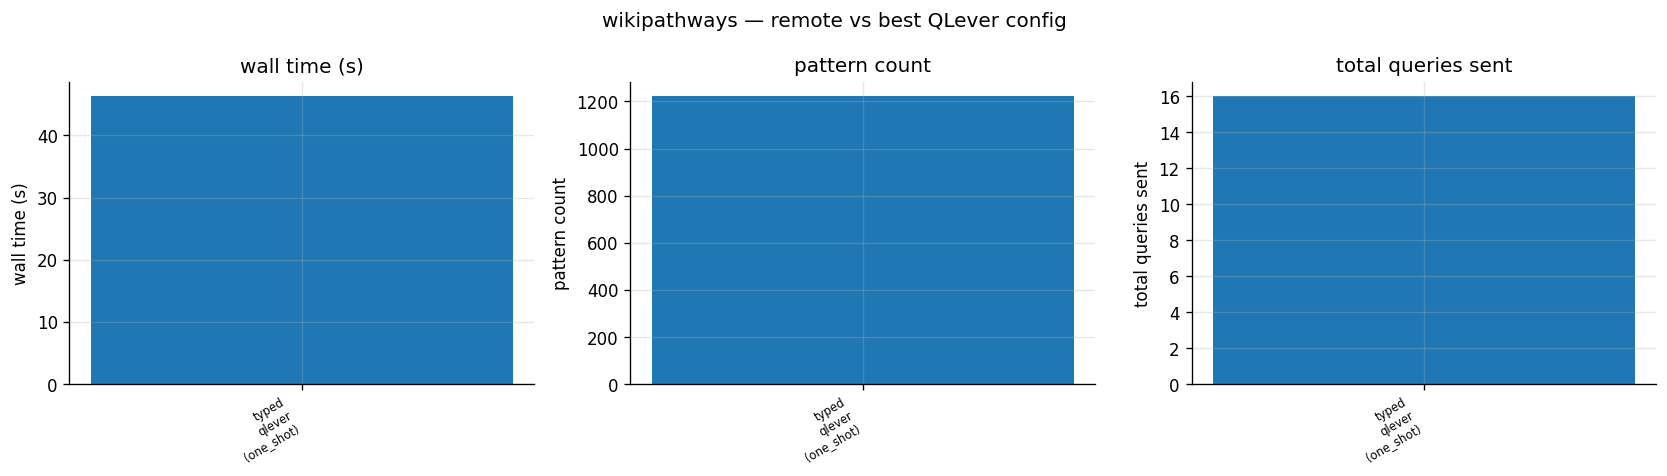

In [39]:
# Best QLever config per (dataset, strategy_variant) = lowest wall_time_s
qlever_best = (
    df[df["endpoint_type"] == "qlever"]
    .sort_values("wall_time_s")
    .groupby(["dataset", "strategy_variant"], as_index=False)
    .first()
)
qlever_best["source"] = "qlever\n(" + qlever_best["config_label"] + ")"

remote = df[df["endpoint_type"] == "remote"].copy()
remote["source"] = "remote"

cmp = pd.concat([
    qlever_best[["dataset", "strategy_variant", "source", "wall_time_s", "pattern_count", "total_queries_sent"]],
    remote[["dataset", "strategy_variant", "source", "wall_time_s", "pattern_count", "total_queries_sent"]],
], ignore_index=True)

for dataset, grp in cmp.groupby("dataset"):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, metric, ylabel in zip(
        axes,
        ["wall_time_s", "pattern_count", "total_queries_sent"],
        ["wall time (s)", "pattern count", "total queries sent"], strict=False,
    ):
        x = range(len(grp))
        bars = ax.bar(x, grp[metric].fillna(0), width=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(
            grp["strategy_variant"] + "\n" + grp["source"],
            fontsize=7, rotation=30, ha="right",
        )
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)

    fig.suptitle(f"{dataset} - remote vs best QLever config")
    fig.tight_layout()
    plt.show()


## One-shot vs paginated: timing and query count

One-shot issues a single unbounded SELECT per pattern type; paginated uses OFFSET/LIMIT pages.
Comparison per dataset × strategy variant.


In [40]:
qlever_df = df[df["endpoint_type"] == "qlever"].copy()

for dataset, grp in qlever_df.groupby("dataset"):
    for variant, sub in grp.groupby("strategy_variant"):
        one_shot_row = sub[sub["one_shot"]]
        pag_rows     = sub[~sub["one_shot"]].sort_values("chunk_size")

        if one_shot_row.empty or pag_rows.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # -- left: wall time
        ax = axes[0]
        ax.axhline(
            one_shot_row["wall_time_s"].values[0],
            color="tab:orange", linestyle="--", linewidth=1.5, label="one-shot",
        )
        for batch, psub in pag_rows.groupby("class_batch_size"):
            psub = psub.sort_values("chunk_size")
            ax.plot(psub["chunk_size"], psub["wall_time_s"], marker="o", label=f"pag batch={int(batch)}")
        ax.set_xlabel("chunk size (rows/page)")
        ax.set_ylabel("wall time (s)")
        ax.set_title(f"{dataset} / {variant} - wall time")
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

        # -- right: total queries sent
        ax = axes[1]
        ax.axhline(
            one_shot_row["total_queries_sent"].values[0],
            color="tab:orange", linestyle="--", linewidth=1.5, label="one-shot",
        )
        for batch, psub in pag_rows.groupby("class_batch_size"):
            psub = psub.sort_values("chunk_size")
            ax.plot(psub["chunk_size"], psub["total_queries_sent"], marker="s", label=f"pag batch={int(batch)}")
        ax.set_xlabel("chunk size (rows/page)")
        ax.set_ylabel("queries sent")
        ax.set_title(f"{dataset} / {variant} - query count")
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

        fig.tight_layout()
        plt.show()


## One-shot individual query durations

`one_shot_results` records duration and row count per query type (typed-object, literal, untyped-uri).


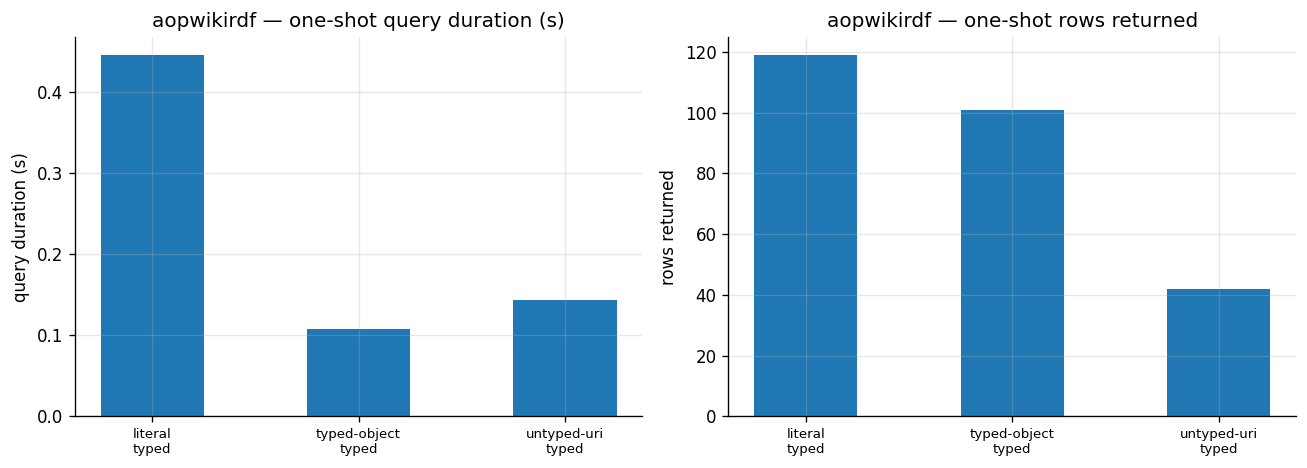

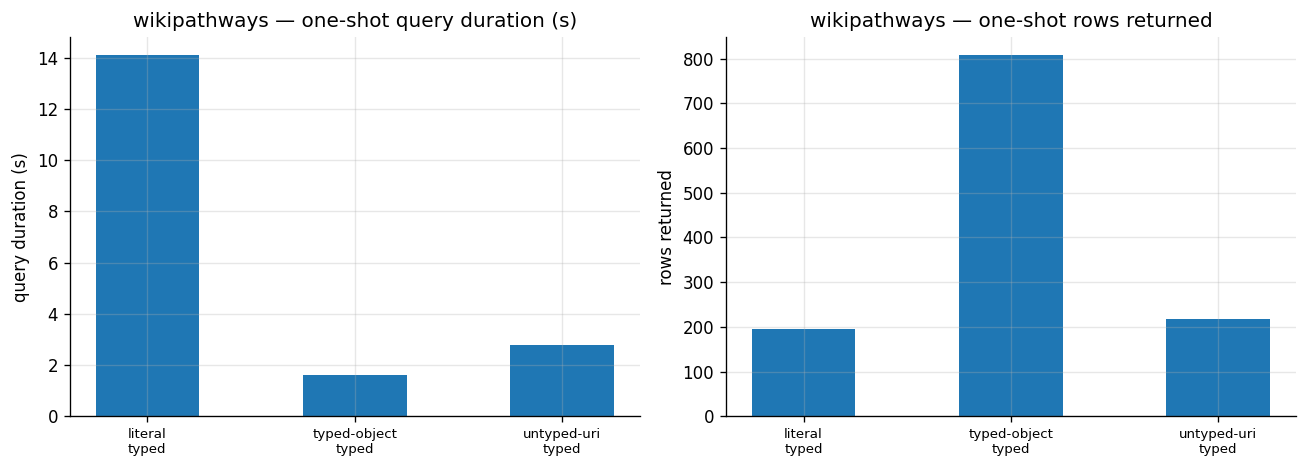

In [41]:
os_rows = df[df["one_shot_results"].notna()].copy()

if os_rows.empty:
    print("No one_shot_results found.")
else:
    records = []
    for _, row in os_rows.iterrows():
        for qr in row["one_shot_results"]:
            records.append({
                "dataset":          row["dataset"],
                "strategy_variant": row["strategy_variant"],
                "query_type":       qr["query_type"],
                "duration_s":       qr.get("duration_s"),
                "row_count":        qr.get("row_count"),
                "success":          qr.get("success", True),
            })
    os_df = pd.DataFrame(records)

    for dataset, grp in os_df.groupby("dataset"):
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))

        for ax, metric, ylabel in zip(
            axes,
            ["duration_s", "row_count"],
            ["query duration (s)", "rows returned"], strict=False,
        ):
            for variant, sub in grp.groupby("strategy_variant"):
                sub = sub.sort_values("query_type")
                ax.bar(
                    [f"{qt}\n{variant}" for qt in sub["query_type"]],
                    sub[metric].fillna(0),
                    label=variant,
                    width=0.5,
                )
            ax.set_ylabel(ylabel)
            ax.set_title(f"{dataset} - one-shot {ylabel}")
            ax.tick_params(axis="x", labelsize=8)

        fig.tight_layout()
        plt.show()


## Summary table

All runs ranked by wall time within each dataset.


In [42]:
summary_cols = [
    "dataset", "endpoint_type", "strategy_variant", "config_label",
    "chunk_size", "class_batch_size",
    "wall_time_s", "total_duration_s", "total_queries_sent",
    "pattern_count", "class_count", "property_count",
    "t_class_discovery_s", "t_per_class_s", "t_counts_s", "t_labels_s",
    "peak_rss_mb", "success",
]
(
    df[summary_cols]
    .sort_values(["dataset", "wall_time_s"])
    .reset_index(drop=True)
    .style.format({
        "wall_time_s":          "{:.2f}",
        "total_duration_s":     "{:.2f}",
        "t_class_discovery_s":  "{:.3f}",
        "t_per_class_s":        "{:.3f}",
        "t_counts_s":           "{:.3f}",
        "t_labels_s":           "{:.3f}",
        "peak_rss_mb":          "{:.1f}",
        "chunk_size":           lambda v: f"{int(v):,}" if pd.notna(v) else "",
    }, na_rep="-")
    .background_gradient(subset=["wall_time_s"], cmap="YlOrRd")
)


,dataset,endpoint_type,strategy_variant,config_label,chunk_size,class_batch_size,wall_time_s,total_duration_s,total_queries_sent,pattern_count,class_count,property_count,t_class_discovery_s,t_per_class_s,t_counts_s,t_labels_s,peak_rss_mb,success
0,aopwikirdf,qlever,typed,one_shot,"10,000",-,7.59,2.62,11,262,28,72,0.000,0.000,1.775,0.141,271.3,True
1,wikipathways,qlever,typed,one_shot,"10,000",-,46.25,41.42,16,1221,39,121,0.000,0.000,22.617,0.284,277.1,True


## Variable contribution to wall time

Quantifies how each observable feature (endpoint size, schema complexity, pagination parameters, …)
contributes to `wall_time_s` across *all* runs and endpoints combined.

Four complementary views:
1. **Correlation matrix** - linear pairwise relationships
2. **OLS standardised β coefficients** - marginal contribution in std-dev units, holding others fixed
3. **Partial-regression plots** - isolate each predictor's marginal effect after partialling out all others
4. **SHAP values on a gradient-boosted model** - model-agnostic, captures non-linearities and interactions

In [43]:
import warnings

import numpy as np
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# ── 1. Build the modelling frame ──────────────────────────────────────────────
# Exclude one-shot runs (no chunk_size / class_batch_size) and rows with no
# wall_time_s.  We keep both qlever and remote rows so the model is endpoint-
# agnostic; endpoint_type is included as a binary dummy.

FEATURES = {
    "triple_count":      "endpoint size (triples)",
    "class_count":       "# classes found",
    "pattern_count":     "# patterns found",
    "chunk_size":        "chunk size (page rows)",
    "class_batch_size":  "class batch size",
    "total_queries_sent":"queries sent",
}

mdf = (
    df[~df["one_shot"] & df["wall_time_s"].notna()]
    .copy()
    .assign(is_qlever=(df["endpoint_type"] == "qlever").astype(float))
)

feature_cols = [*list(FEATURES.keys()), "is_qlever"]
mdf = mdf[[*feature_cols, "wall_time_s"]].dropna(subset=[*feature_cols, "wall_time_s"])

print(f"Modelling frame: {len(mdf)} rows × {len(feature_cols)} features")
mdf.describe().round(1)


Modelling frame: 0 rows × 7 features


,triple_count,class_count,pattern_count,chunk_size,class_batch_size,total_queries_sent,is_qlever,wall_time_s
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


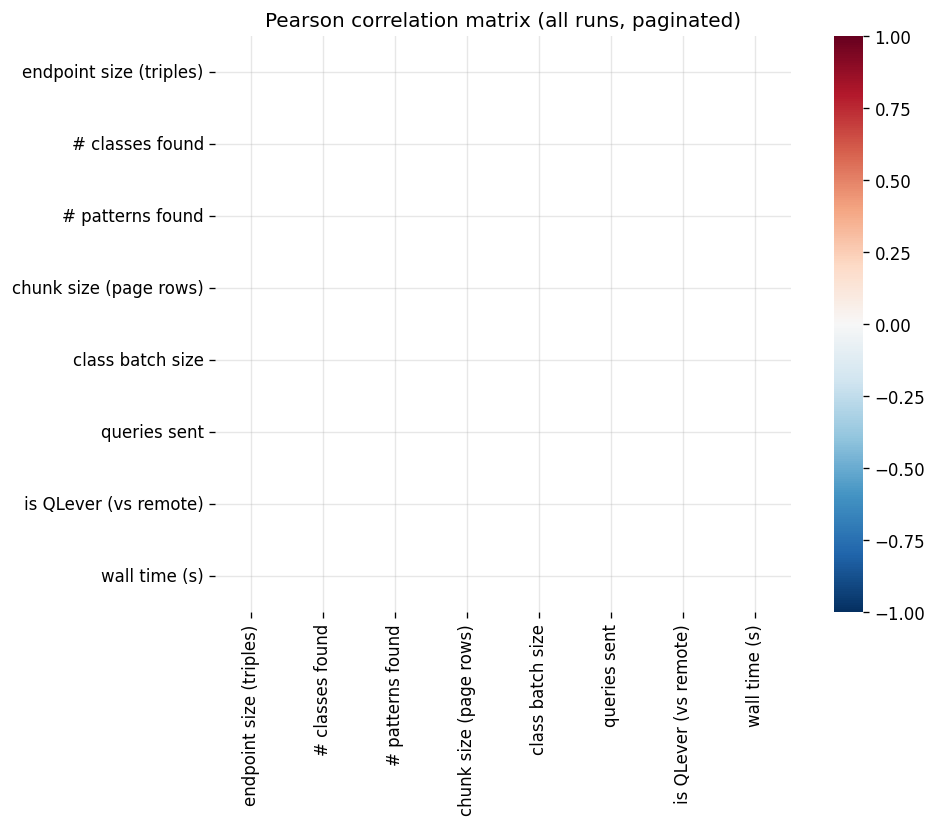

In [45]:
import seaborn as sns

# ── 2. Correlation matrix ─────────────────────────────────────────────────────
corr_cols = [*feature_cols, "wall_time_s"]
corr = mdf[corr_cols].corr()

pretty_names = {**FEATURES, "is_qlever": "is QLever (vs remote)", "wall_time_s": "wall time (s)"}
corr.index   = [pretty_names.get(c, c) for c in corr.index]
corr.columns = [pretty_names.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper triangle (keep lower)
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, square=True,
    ax=ax,
)
ax.set_title("Pearson correlation matrix (all runs, paginated)")
fig.tight_layout()
plt.show()


In [46]:
# ── 3. OLS standardised β coefficients ───────────────────────────────────────
# Standardise every column (mean=0, std=1) so coefficients are directly
# comparable in units of "standard deviations of wall_time_s per std-dev of X".

scaler = StandardScaler()
X_raw  = mdf[feature_cols].values
y_raw  = mdf["wall_time_s"].values

X_std = scaler.fit_transform(X_raw)
y_std = StandardScaler().fit_transform(y_raw.reshape(-1, 1)).ravel()

X_sm  = sm.add_constant(X_std)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ols = sm.OLS(y_std, X_sm).fit()

beta_df = pd.DataFrame({
    "feature":  [pretty_names.get(c, c) for c in feature_cols],
    "beta":     ols.params[1:],
    "se":       ols.bse[1:],
    "p_value":  ols.pvalues[1:],
}).sort_values("beta", key=abs, ascending=False).reset_index(drop=True)

print(f"OLS R²={ols.rsquared:.3f}  adj-R²={ols.rsquared_adj:.3f}  n={len(mdf)}")
print()

fig, ax = plt.subplots(figsize=(8, 0.55 * len(beta_df) + 1.5))
colors = ["tab:red" if b > 0 else "tab:blue" for b in beta_df["beta"]]
bars   = ax.barh(beta_df["feature"], beta_df["beta"], color=colors, height=0.55)
ax.errorbar(
    beta_df["beta"], range(len(beta_df)),
    xerr=1.96 * beta_df["se"],
    fmt="none", color="black", capsize=3, linewidth=1,
)
ax.axvline(0, color="black", linewidth=0.8)

# significance stars
for i, (_, row) in enumerate(beta_df.iterrows()):
    star = "***" if row.p_value < 0.001 else ("**" if row.p_value < 0.01 else ("*" if row.p_value < 0.05 else ""))
    if star:
        xpos = row.beta + np.sign(row.beta) * (1.96 * row.se + 0.01)
        ax.text(xpos, i, star, va="center", ha="left" if row.beta > 0 else "right", fontsize=9)

ax.set_xlabel("Standardised β  (std-devs of wall time per std-dev of predictor)")
ax.set_title(f"OLS standardised coefficients  (R²={ols.rsquared:.2f})")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

beta_df


ValueError: Found array with 0 sample(s) (shape=(0, 7)) while a minimum of 1 is required by StandardScaler.

In [ ]:
# ── 4. Partial-regression (added-variable) plots ─────────────────────────────
# Each panel shows the effect of one predictor on wall_time_s after both
# have been partialled out of all other predictors.  The slope equals the OLS β.

n_feat  = len(feature_cols)
ncols_p = 3
nrows_p = -(-n_feat // ncols_p)   # ceiling division

fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(5 * ncols_p, 4 * nrows_p))
axes_flat = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes_flat[i]
    others = [c for c in feature_cols if c != col]

    # Residualise y and x_i on all other predictors
    X_others = sm.add_constant(mdf[others].values)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res_y = sm.OLS(y_raw, X_others).fit().resid
        res_x = sm.OLS(mdf[col].values, X_others).fit().resid

    ax.scatter(res_x, res_y, s=18, alpha=0.55, color="steelblue")

    # fit line
    if res_x.std() > 0:
        fit = np.polyfit(res_x, res_y, 1)
        xr  = np.linspace(res_x.min(), res_x.max(), 100)
        ax.plot(xr, np.polyval(fit, xr), color="tab:orange", linewidth=1.5)

    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_xlabel(f"e({pretty_names.get(col, col)} | others)", fontsize=7)
    ax.set_ylabel("e(wall time | others)", fontsize=7)
    ax.set_title(pretty_names.get(col, col), fontsize=9)

for ax in axes_flat[n_feat:]:
    ax.set_visible(False)

fig.suptitle("Partial-regression (added-variable) plots", y=1.01)
fig.tight_layout()
plt.show()


In [ ]:
# ── 5. SHAP values on a Gradient-Boosted model ───────────────────────────────
# GBM captures non-linear relationships and interactions that OLS cannot.
# SHAP decomposes each prediction into per-feature additive contributions.
# Mean |SHAP| across all rows gives a model-agnostic importance ranking.

try:
    import shap
    _HAS_SHAP = True
except ImportError:
    _HAS_SHAP = False
    print("shap not installed - run `pip install shap` for the SHAP plot.")

gbm = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                subsample=0.8, random_state=42)
gbm.fit(X_raw, y_raw)

gbm_r2 = gbm.score(X_raw, y_raw)
print(f"GBM train R²={gbm_r2:.3f}  (in-sample; interpret cautiously with small n={len(mdf)})")

feat_labels = [pretty_names.get(c, c) for c in feature_cols]

if _HAS_SHAP:
    explainer   = shap.TreeExplainer(gbm)
    shap_values = explainer.shap_values(X_raw)          # shape (n, p)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_df = (
        pd.DataFrame({"feature": feat_labels, "mean_abs_shap": mean_abs_shap})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Left: mean |SHAP| bar chart
    ax = axes[0]
    ax.barh(shap_df["feature"], shap_df["mean_abs_shap"],
            color="steelblue", height=0.6)
    ax.set_xlabel("Mean |SHAP value|  (impact on wall-time prediction, seconds)")
    ax.set_title("GBM feature importance via SHAP")
    ax.invert_yaxis()

    # Right: beeswarm - each point is one run, x=SHAP value, colour=feature value
    ax = axes[1]
    # Sort features by importance (top first)
    feat_order = shap_df["feature"].tolist()
    feat_idx   = [feat_labels.index(f) for f in feat_order]

    y_pos = 0
    for fi in feat_idx:
        sv     = shap_values[:, fi]
        fv_raw = X_raw[:, fi]
        # normalise feature values to [0,1] for colour mapping
        fv_norm = (fv_raw - fv_raw.min()) / (fv_raw.ptp() + 1e-9)
        # jitter to avoid overplotting
        jitter  = np.random.default_rng(fi).uniform(-0.2, 0.2, size=len(sv))
        sc = ax.scatter(sv, y_pos + jitter, c=fv_norm, cmap="coolwarm",
                        s=18, alpha=0.7, vmin=0, vmax=1)
        y_pos += 1

    ax.set_yticks(range(len(feat_order)))
    ax.set_yticklabels(feat_order, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("SHAP value  (seconds)")
    ax.set_title("SHAP beeswarm  (red = high feature value)")
    cb = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
    cb.set_label("feature value\n(normalised)", fontsize=7)

    fig.tight_layout()
    plt.show()

    print("\nFeature importance ranked by mean |SHAP|:")
    display(shap_df)

else:
    # Fallback: sklearn feature_importances_ (MDI)
    imp_df = (
        pd.DataFrame({"feature": feat_labels, "importance": gbm.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(imp_df["feature"], imp_df["importance"], color="steelblue", height=0.6)
    ax.set_xlabel("Mean decrease in impurity (MDI importance)")
    ax.set_title("GBM feature importance (install shap for SHAP values)")
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()
    display(imp_df)


---
## QLever index warnings

Loads `index_warnings.json` produced by `run_pipeline.sh` after each
`qlever index` step.  Shows total warning counts per dataset and a
breakdown of distinct warning types.

In [ ]:
# ── Load index_warnings.json ─────────────────────────────────────────────────
if not INDEX_WARNINGS_PATH.exists():
    print(f"index_warnings.json not found at {INDEX_WARNINGS_PATH}")
    print("Run the pipeline first, or set INDEX_WARNINGS env var.")
    warn_data = {}
else:
    warn_data = json.loads(INDEX_WARNINGS_PATH.read_text())
    print(f"Loaded warnings for {len(warn_data)} dataset(s): {', '.join(warn_data)}")

# Flatten to a DataFrame: one row per (dataset, warning_type)
rows = []
for ds, entry in warn_data.items():
    total = entry.get("total_warnings", 0)
    ts = entry.get("generated_utc", "")
    breakdown = entry.get("breakdown", {})
    if breakdown:
        for msg, count in breakdown.items():
            rows.append({"dataset": ds, "warning_type": msg.strip(), "count": count,
                         "total_warnings": total, "generated_utc": ts})
    else:
        rows.append({"dataset": ds, "warning_type": "(none)", "count": 0,
                     "total_warnings": 0, "generated_utc": ts})

warn_df = pd.DataFrame(rows, columns=["dataset", "warning_type", "count",
                                       "total_warnings", "generated_utc"])

# Summary table: total warnings per dataset
summary = (
    warn_df.groupby("dataset")[["total_warnings", "generated_utc"]]
    .first()
    .sort_values("total_warnings", ascending=False)
    .reset_index()
)
summary.columns = ["Dataset", "Total warnings", "Index timestamp (UTC)"]
print(summary.to_string(index=False))

In [ ]:
# ── Bar chart: total warnings per dataset ────────────────────────────────────
if not warn_df.empty and warn_df["total_warnings"].sum() > 0:
    totals = (
        warn_df.groupby("dataset")["total_warnings"]
        .first()
        .sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(max(5, len(totals) * 0.7), 4))
    colors = ["#d62728" if v > 0 else "#2ca02c" for v in totals.values]
    bars = ax.bar(totals.index, totals.values, color=colors, edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_ylabel("Total WARN lines in index log")
    ax.set_title("QLever index warnings per dataset")
    ax.set_xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No warnings recorded - all datasets indexed cleanly.")

In [ ]:
# ── Breakdown table: warning types per dataset ───────────────────────────────
if not warn_df.empty and warn_df["count"].sum() > 0:
    pivot = (
        warn_df[warn_df["warning_type"] != "(none)"]
        .pivot_table(index="warning_type", columns="dataset",
                     values="count", fill_value=0)
        .astype(int)
    )
    # Clean up type labels: strip the leading "WARN: " prefix for readability
    pivot.index = pivot.index.str.replace(r"^WARN:\s*", "", regex=True)
    pivot.index.name = "Warning type"
    pivot = pivot.sort_values(pivot.columns.tolist(), ascending=False)
    display(pivot.style
            .background_gradient(cmap="YlOrRd", axis=None)
            .format("{:,}")
            .set_caption("Warning counts by type and dataset (0 = clean)"))
else:
    print("No warning breakdown to display.")